# NLP Assignment 1 (40% of grade): Sentiment Analysis from Tweets

This coursework will involve you implementing functions for a text classifier, which you will train to identify the **sentiment expressed in a text** in a dataset of approx. 27,000 entries, which will be split into a 80%/20% training/test split. 

In this template you are given the basis for that implementation, though some of the functions are missing, which you have to fill in.

Follow the instructions file **NLP_Assignment_1_Instructions.pdf** for details of each question - the outline of what needs to be achieved for each question is as below.

You must submit all **ipython notebooks and extra resources you need to run the code if you've added them** in the code submission, and a **2 page report (pdf)** in the report submission on QMPlus where you report your methods and findings according to the instructions file for each question. **NB:** this report is strictly limited to 2 pages, and any additional pages will not be considered during marking. You are expected to write concisely within the 2 pages, and any additional texts beyond this will not be considered as part of the report.

In [1]:
import csv                               # csv reader
from sklearn.svm import LinearSVC
from nltk.classify import SklearnClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_recall_fscore_support # to report on precision and recall
import numpy as np

In [2]:
def load_data(path):
    """Load data from a tab-separated file and append it to raw_data."""
    with open(path) as f:
        reader = csv.reader(f, delimiter='\t')
        for line in reader:
            (label, text) = parse_data_line(line)
            raw_data.append((text, label))

def split_and_preprocess_data(percentage):
    """Split the data between train_data and test_data according to the percentage
    and performs the preprocessing."""
    num_samples = len(raw_data)
    num_training_samples = int((percentage * num_samples))
    for (text, label) in raw_data[:num_training_samples]:
        #changed this : train_data.append((to_feature_vector(pre_process(text)),label))
        #TO KEEP RAW DATA/TEXT for question 3 error analysis:
        train_data.append((to_feature_vector(pre_process(text)),label, text))
    for (text, label) in raw_data[num_training_samples:]:
        #chnaged this: test_data.append((to_feature_vector(pre_process(text)),label))
        #TO KEEP RAW DATA/TEXT for question 3 error analysis:
        test_data.append((to_feature_vector(pre_process(text)),label, text))
        
def parse_data_line(data_line):
    """Return a tuple of the label as just FAKE or REAL and the statement"""
    #it is not fake or real, its negative or positive for sentiment analysis!!
    return (data_line[1], data_line[2])

def pre_process(text):
    """Return a list of tokens"""
    return text.split()

In [3]:
# test
text = "RT @colonelkickhead: Another bloody instant restaurant week?!?! Seriously! They just jumped the shark riding two other sharks powered by sh…"
pre_process(text)

['RT',
 '@colonelkickhead:',
 'Another',
 'bloody',
 'instant',
 'restaurant',
 'week?!?!',
 'Seriously!',
 'They',
 'just',
 'jumped',
 'the',
 'shark',
 'riding',
 'two',
 'other',
 'sharks',
 'powered',
 'by',
 'sh…']

# Question 1: Basic Feature Extraction (10 marks)

In [4]:
global_feature_dict = {} # a global dictionary of features

def to_feature_vector(tokens):
    #given a preprocessed list of tokens, return a dictionary containing features as keys, and weights as values
    feature_vector = {}
    #iterate through tokens and add weights/counts to feature_vector
    for token in tokens:
        feature_vector[token] = feature_vector.get(token, 0) + 1
        global_feature_dict[token] = global_feature_dict.get(token, 0) + 1 #update global feature dict. not needed.
    return feature_vector

In [5]:
# TRAINING AND VALIDATING OUR CLASSIFIER

def train_classifier(data):
    #as i added raw data in q3, here change train_data to ignore raw data as linearSVC expects (features,labels) only. 2 max values to unpack. 
    train_data = [(features, label) for (features, label, text) in data]
    print("Training Classifier...")
    pipeline =  Pipeline([('svc', LinearSVC())])
    return SklearnClassifier(pipeline).train(train_data)

# Question 2: Cross-validation (20 marks)

In [6]:
#solution
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_fscore_support, accuracy_score


def cross_validate(dataset, folds):
    results = []
    fold_size = int(len(dataset)/folds) + 1
    
    np.random.shuffle(dataset)  #shuffle dataset before splitting into folds
    
    for i in range(0,len(dataset),int(fold_size)):
        # insert code here that trains and tests on the 10 folds of data in the dataset
        print("Fold start on items %d - %d" % (i, i+fold_size))
        # FILL IN THE METHOD HERE
        
        #split into train and vald folds. if fold size 10= 1 val fold and 9 train folds
        val_fold = dataset[i:i+fold_size]
        train_fold = dataset[:i] + dataset[i+fold_size:]
        
        #train classifier on train folds
        classifier = train_classifier(train_fold)
        
        #features and labels of the val fold 
        val_features = [features for (features, label, text) in val_fold]
        true_labels = [label for (features, label, text) in val_fold]
            
        #predict labels using trained classifier
        predicted_labels = predict_labels(val_features, classifier)
        
        #calculate metrics
        precision, recall, f1_score, _ = precision_recall_fscore_support(true_labels, predicted_labels, average='weighted')
        accuracy = accuracy_score(true_labels, predicted_labels)
        
        #append results of this fold
        results.append({'precision': precision, 'recall': recall, 'f1_score': f1_score, 'accuracy': accuracy})
        
    #average results across folds
    cv_results = {}
    for metric in results[0].keys():
        cv_results[metric] = np.mean([result[metric] for result in results])
    
    #debug print
    #print("Cross-Validation Results:")
    #for metric, value in cv_results.items():
    #    print(f"{metric}: {value:.3f}")
    
    return cv_results

In [7]:
# PREDICTING LABELS GIVEN A CLASSIFIER

def predict_labels(samples, classifier):
    """Assuming preprocessed samples, return their predicted labels from the classifier model."""
    return classifier.classify_many(samples)

def predict_label_from_raw(sample, classifier):
    """Assuming raw text, return its predicted label from the classifier model."""
    return classifier.classify(to_feature_vector(pre_process(sample)))

In [8]:
# MAIN

# loading reviews
# initialize global lists that will be appended to by the methods below
raw_data = []          # the filtered data from the dataset file
train_data = []        # the pre-processed training data as a percentage of the total dataset
test_data = []         # the pre-processed test data as a percentage of the total dataset


# references to the data files
data_file_path = 'sentiment-dataset.tsv'

# Do the actual stuff (i.e. call the functions we've made)
# We parse the dataset and put it in a raw data list
print("Now %d rawData, %d trainData, %d testData" % (len(raw_data), len(train_data), len(test_data)),
      "Preparing the dataset...",sep='\n')

load_data(data_file_path) 

# We split the raw dataset into a set of training data and a set of test data (80/20)
# You do the cross validation on the 80% (training data)
# We print the number of training samples and the number of features before the split
print("Now %d rawData, %d trainData, %d testData" % (len(raw_data), len(train_data), len(test_data)),
      "Preparing training and test data...",sep='\n')

split_and_preprocess_data(0.8)

# We print the number of training samples and the number of features after the split
print("After split, %d rawData, %d trainData, %d testData" % (len(raw_data), len(train_data), len(test_data)),
      "Training Samples: ", len(train_data), "Features: ", len(global_feature_dict), sep='\n')


Now 0 rawData, 0 trainData, 0 testData
Preparing the dataset...
Now 33540 rawData, 0 trainData, 0 testData
Preparing training and test data...
After split, 33540 rawData, 26832 trainData, 6708 testData
Training Samples: 
26832
Features: 
104038


In [9]:
cross_validate(train_data, 10)  # will work and output overall performance of p, r, f-score when cv implemented

Fold start on items 0 - 2684
Training Classifier...


/Applications/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Fold start on items 2684 - 5368
Training Classifier...


/Applications/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Fold start on items 5368 - 8052
Training Classifier...


...

Fold start on items 21472 - 24156
Training Classifier...


/Applications/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Fold start on items 24156 - 26840
Training Classifier...


/Applications/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


{'precision': 0.8325108560279137,
 'recall': 0.8343410767232718,
 'f1_score': 0.8326989655410928,
 'accuracy': 0.8343410767232718}

# Question 3: Error Analysis (20 marks)

In [10]:
from sklearn import metrics
import matplotlib.pyplot as plt
# a function to make the confusion matrix readable and pretty
def confusion_matrix_heatmap(y_test, preds, labels):
    """Function to plot a confusion matrix"""
    # pass labels to the confusion matrix function to ensure right order
    cm = metrics.confusion_matrix(y_test, preds, labels=labels)
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111)
    cax = ax.matshow(cm)
    plt.title('Confusion matrix of the classifier')
    fig.colorbar(cax)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels( labels, rotation=45)
    ax.set_yticklabels( labels)

    for i in range(len(cm)):
        for j in range(len(cm)):
            text = ax.text(j, i, cm[i, j],
                           ha="center", va="center", color="w")

    plt.xlabel('Predicted')
    plt.ylabel('True')
    
    # fix for mpl bug that cuts off top/bottom of seaborn viz:
    b, t = plt.ylim() # discover the values for bottom and top
    b += 0.5 # Add 0.5 to the bottom
    t -= 0.5 # Subtract 0.5 from the top
    plt.ylim(b, t) # update the ylim(bottom, top) values
    plt.show() # ta-da!
    plt.show()

In [11]:
## reuse first fold of cross validation for error analysis. train on 9/10 of training data and test on 1/10
#focus in one class (positive label) == target_label

def error_analysis(dataset, target_label='positive'):
    #one split of cross validation for error analysis. one train/test split
    fold_size = int(len(dataset)/10)
    val_fold = dataset[:fold_size]
    train_fold = dataset[fold_size:]
    
    #train classifier
    classifier = train_classifier(train_fold)
    
    #val data on val fold. changed splitandpreprocess to keep raw text: (features, label, text)
    val_features = [features for (features, label, text) in val_fold]
    true_labels = [label for (features, label, text) in val_fold]
    raw_texts = [text for (features, label, text) in val_fold]
        
    #predict labels using trained classifier
    predicted_labels = predict_labels(val_features, classifier)
    
    #plot confusion matrix
    labels = sorted(list(set(true_labels)))
    confusion_matrix_heatmap(true_labels, predicted_labels, labels)
    
    #n = num of examples. 15 examples. because canot study all
    fp_count = 0
    fn_count = 0
    
    #write it to two files: false positives and false negatives
    with open('false_positives.txt', 'w') as fp_file:
        fp_file.write("=== FALSE POSITIVES ===\n")
        for pred, true, text in zip(predicted_labels, true_labels, raw_texts):
            if pred == target_label and true != target_label: #as my target_label=pos. its finding predicted=pos and true=neg
                fp_file.write(f"Predicted: {pred}, True/Ground Truth: {true}\nText: {text}\n")
                fp_file.write("-" * 70 + "\n")
                fp_count += 1
                if fp_count >= 15: #if 15 examples stop
                    break
        
    with open('false_negatives.txt', 'w') as fn_file:
        fn_file.write("=== FALSE NEGATIVES ===\n")
        for pred, true, text in zip(predicted_labels, true_labels, raw_texts):
            if pred != target_label and true == target_label: #as my target_label=pos. its finding predicted=neg and true=pos
                fn_file.write(f"Predicted: {pred}, True/Ground Truth: {true}\nText: {text}\n")
                fn_file.write("-" * 70 + "\n")
                fn_count += 1
                if fn_count >= 15: #if 15 examples stop
                    break
    
    print("Error analysis completed")

Training Classifier...


/Applications/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


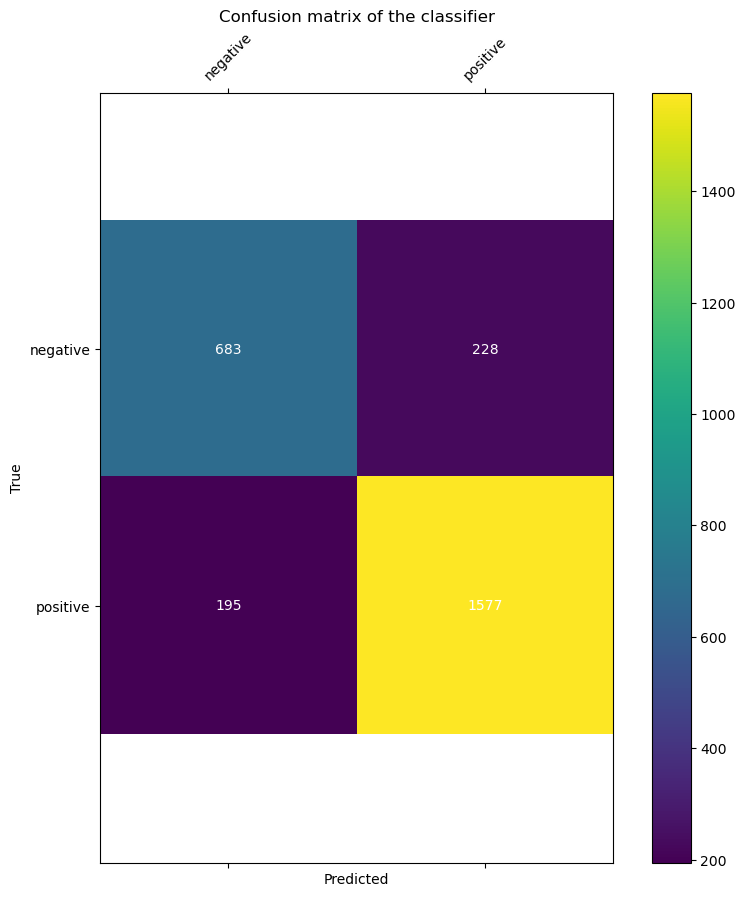

Error analysis completed


In [12]:
error_analysis(train_data, target_label='positive')